# pycopykat quickstart

End-to-end demo on R copykat's bundled `exp.rawdata` fixture (302 cells × 33,694 genes). This notebook drives `from pycopykat import copykat` directly — no R, no rpy2, no Bioconductor.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr

import pycopykat
from pycopykat import CopykatConfig, copykat

FIXTURE = '/media/jason/T7/rerbulid/copykat-R/data/exp.rawdata.rda'
print('pycopykat version:', pycopykat.__version__)


pycopykat version: 0.1.0.dev0


## 1. Load the canonical counts matrix

`exp.rawdata` is a dense genes × cells integer matrix shipped with the upstream R [CopyKAT](https://github.com/navinlabcode/copykat) package.

In [2]:
counts = next(iter(pyreadr.read_r(FIXTURE).values()))
print('shape (genes x cells):', counts.shape)
counts.iloc[:4, :4]


shape (genes x cells): (33694, 302)


,AAACCTGCACCTTGTC,AAACGGGAGTCCTCCT,AAACGGGTCCAGAGGA,AAAGATGCAGTTTACG
rownames,,,,
RP11-34P13.3,0,0,0,0
FAM138A,0,0,0,0
OR4F5,0,0,0,0
RP11-34P13.7,0,0,0,0


## 2. Run `copykat` with the unsupervised auto-baseline

`n_jobs=1` keeps the notebook output deterministic at the expense of wall-clock time; raise it for production.

In [3]:
result = copykat(
    counts,
    config=CopykatConfig(sam_name='exp_rawdata', n_jobs=1),
)
print('prediction columns:', list(result.prediction.columns))
print('cna_mat shape (bins x cells):', result.cna_mat.shape)
print('linkage matrix shape:', result.linkage.shape)
print('subclone assignments:', len(result.subclone), 'aneuploid cells')
print('warnings:', result.warnings)


prediction columns: ['cell', 'copykat.pred']
cna_mat shape (bins x cells): (12167, 302)
linkage matrix shape: (301, 4)
subclone assignments: 229 aneuploid cells
warnings: ()


## 3. Per-cell aneuploid / diploid prediction

In [4]:
pred = result.prediction
pred.head()


,cell,copykat.pred
0,AAACCTGCACCTTGTC,aneuploid
1,AAACGGGAGTCCTCCT,diploid
2,AAACGGGTCCAGAGGA,aneuploid
3,AAAGATGCAGTTTACG,aneuploid
4,AAAGCAACAGGAATGC,aneuploid


In [5]:
pred_col = 'copykat.pred' if 'copykat.pred' in pred.columns else pred.columns[-1]
pred[pred_col].value_counts()


copykat.pred
aneuploid    229
diploid       73
Name: count, dtype: int64

## 4. Bin × cell CNA matrix — visual sanity check

The CNA matrix is bins × cells; here we render a down-sampled heatmap (first 80 cells) to confirm the expected block structure.

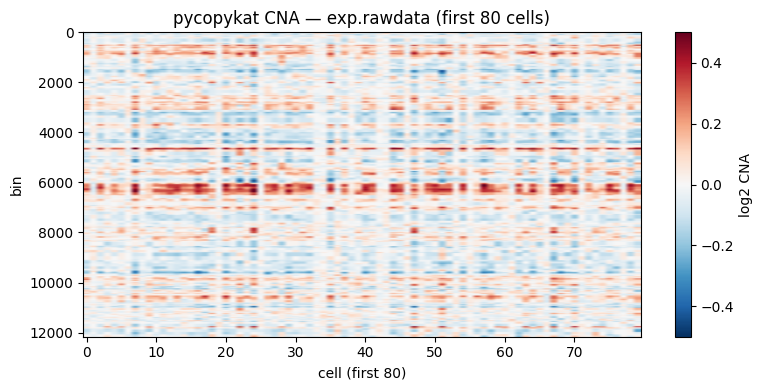

In [6]:
cna = result.cna_mat
subset = cna.iloc[:, :80] if hasattr(cna, 'iloc') else cna[:, :80]
mat = subset.values if hasattr(subset, 'values') else np.asarray(subset)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_xlabel('cell (first 80)')
ax.set_ylabel('bin')
ax.set_title('pycopykat CNA — exp.rawdata (first 80 cells)')
plt.colorbar(im, ax=ax, label='log2 CNA')
plt.tight_layout()
plt.show()


## 5. Where to go next

* AnnData users: `from pycopykat import copykat_by_batch` iterates
  over a batch column in an `.h5ad`.
* CLI equivalent: `uv run pycopykat run-h5ad --input <...> --batch-key <col>`.
* 17-patient py↔R benchmark: see `benchmarks/full/FINDINGS.md`.
